# Notebook 14: SMOTE with Remediated Features

Load data and prepare features.

Run 5-fold LOYOCV (2014-2018) under three conditions per model:
- No SMOTE: class weighting with per-fold threshold calibration
- SMOTE Only: SMOTE applied, default threshold 0.50
- SMOTE + Tuning: SMOTE applied with per-fold threshold calibration on original data

Balanced accuracy is used to choose the best threshold because it gives equal weight to predicting passes and fails.

Grid search tries different settings and picks the one that performs best.

Export results to Excel and save charts.

NOTEBOOK 14_v2: FEATURE IMPORTANCE AND SELECTION (UPDATED)
Results directory: C:\Users\Nikita Danvill\OneDrive - University of Otago\Documents\INFO501\Nikita_Danvill_8887029_JupyterNotebooks_INFO501\Results
Working directory: C:\Users\Nikita Danvill\OneDrive - University of Otago\Documents\INFO501\Nikita_Danvill_8887029_JupyterNotebooks_INFO501

STEP 1: LOADING REMEDIATED FEATURES
Feature matrix : (1154, 21)
Features       : ['num_atmp_l1', 'num_atmp_l2', 'num_atmp_l3', 'num_atmp_l4', 'num_atmp_l5', 'num_atmp_l6', 'num_atmp_l7', 'num_atmp_l8', 'num_atmp_l11', 'wk_comp_l1', 'wk_comp_l2', 'wk_comp_l3', 'wk_comp_l4', 'wk_comp_l5', 'wk_comp_l6', 'wk_comp_l7', 'wk_comp_l8', 'total_attempts_3w', 'levels_completed_3w', 'efficiency_3w', 'total_inactivity_adjusted']
Outcome dist   : Pass=887, Fail=267

STEP 4: LOYOCV EVALUATION (2014-2018) - THREE CONDITIONS

TEST YEAR: 2014
Train: 912 | Test: 242
Train fail rate: 24.2%  Test fail rate: 19.0%

  [Logistic Regression]
    No SMOTE     | threshol

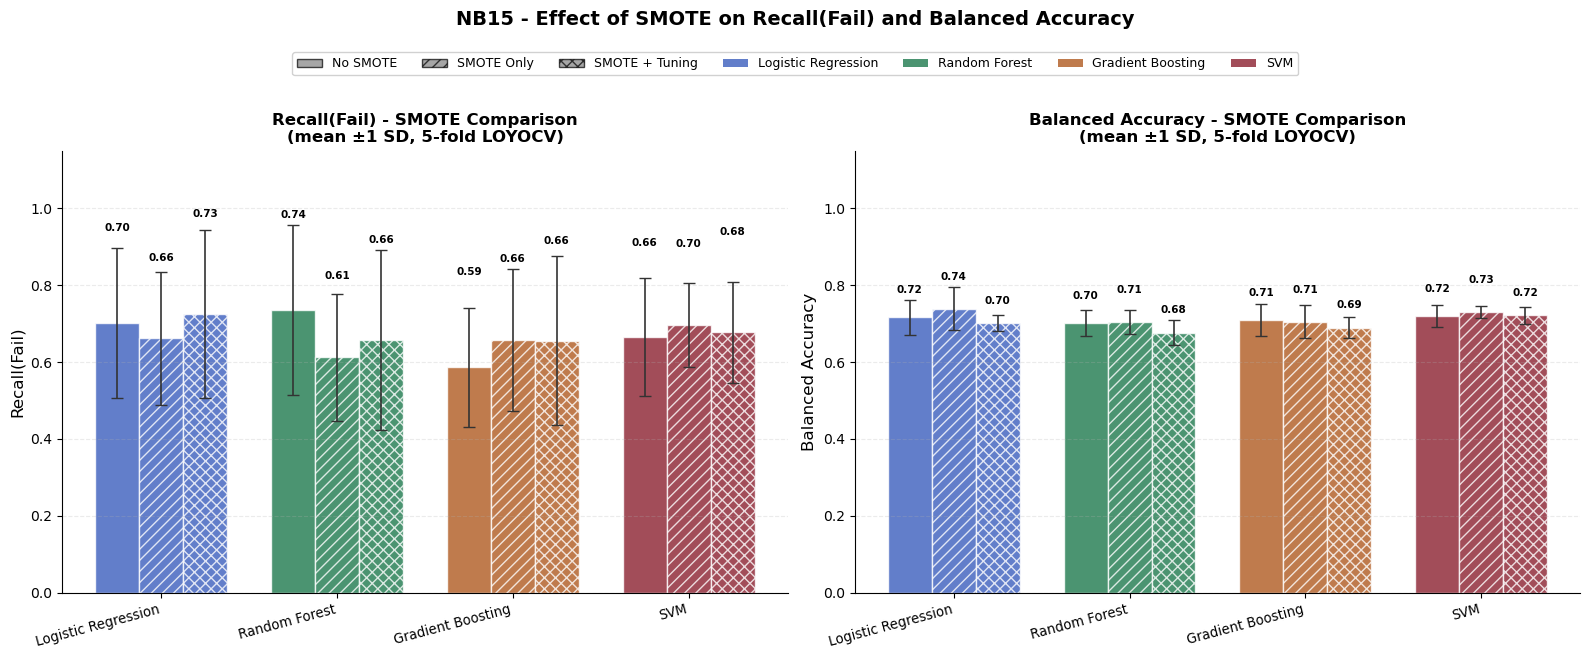

  ✓ Chart 1: SMOTE comparison (Recall + Bal.Acc) saved


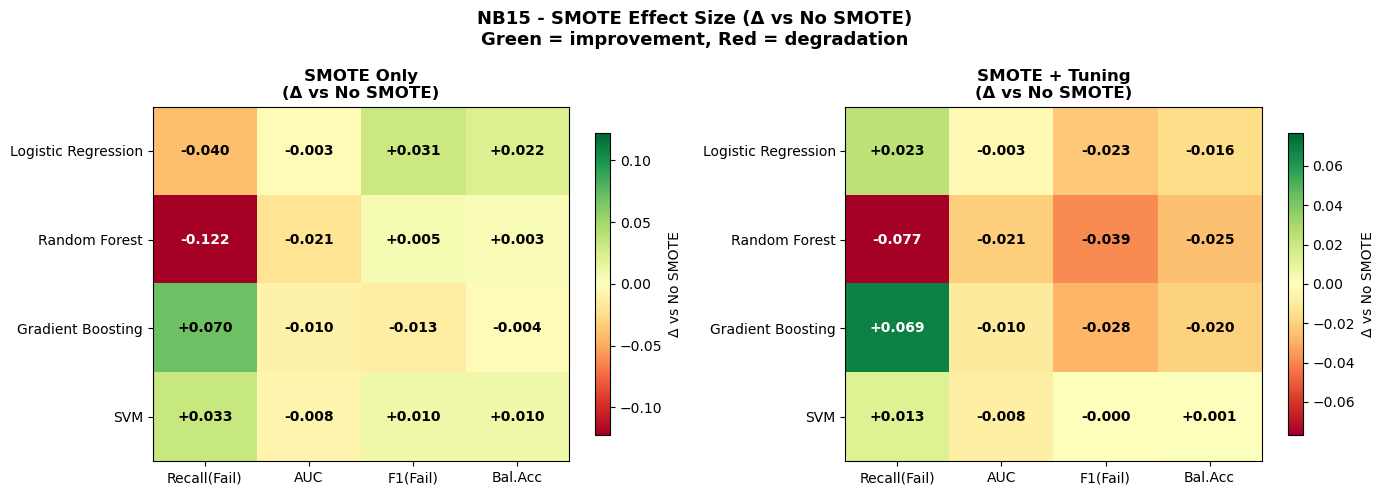

  ✓ Chart 2: SMOTE delta heatmap saved

All NB15 visualizations saved to Results4 folder.

FINAL SUMMARY - NOTEBOOK 15

Model                     Condition          Recall(Fail)     AUC        F1(Fail)     Bal.Acc
-----------------------------------------------------------------------------------------------
Logistic Regression       No SMOTE           0.702±0.219          0.809     0.541      0.717
Logistic Regression       SMOTE Only         0.662±0.194 ↓-0.040  0.806     0.572      0.738
Logistic Regression       SMOTE + Tuning     0.725±0.244 ↑+0.023  0.806     0.518      0.701

Random Forest             No SMOTE           0.735±0.247          0.805     0.523      0.702
Random Forest             SMOTE Only         0.613±0.185 ↓-0.122  0.784     0.528      0.705
Random Forest             SMOTE + Tuning     0.659±0.262 ↓-0.077  0.784     0.484      0.677

Gradient Boosting         No SMOTE           0.587±0.173          0.789     0.535      0.709
Gradient Boosting         SMOTE Only 

In [3]:
# Output directory
import os
RESULTS_DIR = os.path.join(os.getcwd(), "Results")
CHARTS_DIR  = os.path.join(os.getcwd(), "Charts")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHARTS_DIR,  exist_ok=True)

print("=" * 80)
print("NOTEBOOK 14_v2: FEATURE IMPORTANCE AND SELECTION (UPDATED)")
print("=" * 80)
print(f"Results directory: {RESULTS_DIR}")

import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix
)
from imblearn.over_sampling import SMOTE
from sklearn.metrics import make_scorer

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

warnings.filterwarnings("ignore")

# Custom scorer: recall for the fail class
recall_fail_scorer = make_scorer(recall_score, pos_label=0)

os.chdir(".")  # current directory - update if needed
print("Working directory:", os.getcwd())

# =============================================================================
# STEP 1: LOAD REMEDIATED FEATURES
# =============================================================================
print("\n" + "="*80)
print("STEP 1: LOADING REMEDIATED FEATURES")
print("="*80)

modeling_data = pd.read_excel(
    "modeling_dataset.xlsx"  # relative path - place file in same folder as this notebook
)
y        = modeling_data["outcome"]
year_col = modeling_data["year"].copy()

X_remediated = pd.read_csv(os.path.join(RESULTS_DIR, "features_after_zero_ambiguity_fix.csv"))
feature_cols_modeling = [
    c for c in X_remediated.columns
    if c not in ["last_completion_week", "trailing_gap_weeks"]
]
X_model = X_remediated[feature_cols_modeling].copy()

print(f"Feature matrix : {X_model.shape}")
print(f"Features       : {feature_cols_modeling}")
print(f"Outcome dist   : Pass={sum(y==1)}, Fail={sum(y==0)}")

# =============================================================================
# STEP 2: CONFIGURATION
# =============================================================================
TEST_YEARS       = [2014, 2015, 2016, 2017, 2018]
CANDIDATE_THRESHOLDS = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
MODEL_NAMES      = ["Logistic Regression", "Random Forest", "Gradient Boosting", "SVM"]
SMOTE_RANDOM_STATE = 42

# Updated hyperparameter grids: no C=0.001 for LR
PARAM_GRIDS = {
    "Logistic Regression": {"C": [0.01, 0.1, 1.0, 10.0, 100.0]},
    "Random Forest": {
        "n_estimators"   : [100, 200, 300],
        "max_depth"      : [10, 15, None],
        "min_samples_leaf": [1, 3, 5],
    },
    "Gradient Boosting": {
        "n_estimators" : [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth"    : [3, 4, 5],
        "subsample"    : [0.8, 1.0],
    },
    "SVM": {
        "C"    : [0.1, 1.0, 5.0, 10.0],
        "gamma": ["scale", "auto"],
    },
}

# =============================================================================
# STEP 3: HELPERS
# =============================================================================
def make_model(model_name, params=None, balanced_weight=True):
    p = params or {}
    if model_name == "Logistic Regression":
        cw = "balanced" if balanced_weight else None
        return LogisticRegression(max_iter=1000, class_weight=cw, random_state=42, **p)
    elif model_name == "Random Forest":
        cw = "balanced" if balanced_weight else None
        return RandomForestClassifier(class_weight=cw, random_state=42, n_jobs=-1, **p)
    elif model_name == "Gradient Boosting":
        return GradientBoostingClassifier(random_state=42, **p)
    elif model_name == "SVM":
        cw = "balanced" if balanced_weight else None
        return SVC(kernel="rbf", class_weight=cw, probability=True, random_state=42, **p)

def tune_hyperparams(model_name, Xtr, ytr, balanced_weight=True):
    base = make_model(model_name, balanced_weight=balanced_weight)
    cv = GridSearchCV(base, PARAM_GRIDS[model_name], cv=3, scoring=recall_fail_scorer, n_jobs=-1)
    cv.fit(Xtr, ytr)
    return cv.best_params_

def apply_smote(X, y):
    sm = SMOTE(random_state=SMOTE_RANDOM_STATE)
    return sm.fit_resample(X, y)

def scale(Xtr, Xte):
    sc = StandardScaler()
    return sc.fit_transform(Xtr), sc.transform(Xte)

def compute_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    fpr = cm[1,0] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0.0
    return {
        "recall_fail"       : recall_score(y_true, y_pred, pos_label=0),
        "balanced_accuracy" : balanced_accuracy_score(y_true, y_pred),
        "f1_fail"           : f1_score(y_true, y_pred, pos_label=0),
        "auc"               : roc_auc_score(y_true, y_prob),
        "fpr"               : fpr,
    }

def needs_scaling(model_name):
    return model_name in ("Logistic Regression", "SVM")

def find_best_threshold(y_prob_val, y_val):
    """Return threshold that maximises Balanced Accuracy."""
    best_thresh = 0.50
    best_bal_acc = 0.0
    for t in CANDIDATE_THRESHOLDS:
        y_hat = (y_prob_val >= t).astype(int)
        ba = balanced_accuracy_score(y_val, y_hat)
        if ba > best_bal_acc:
            best_bal_acc = ba
            best_thresh = t
    return best_thresh

def is_degenerate(y_pred, thresh=0.80):
    return max(y_pred.mean(), 1 - y_pred.mean()) > thresh

# =============================================================================
# STEP 4: LOYOCV EVALUATION - THREE CONDITIONS
# =============================================================================
print("\n" + "="*80)
print("STEP 4: LOYOCV EVALUATION (2014-2018) - THREE CONDITIONS")
print("="*80)

CONDITIONS = ["No SMOTE", "SMOTE Only", "SMOTE + Tuning"]
results    = {m: {c: [] for c in CONDITIONS} for m in MODEL_NAMES}
settings   = {m: {c: [] for c in CONDITIONS} for m in MODEL_NAMES}

for test_year in TEST_YEARS:
    print(f"\n{'='*70}")
    print(f"TEST YEAR: {test_year}")
    print(f"{'='*70}")

    # True LOYOCV: train on all years except test year
    train_mask = year_col != test_year
    test_mask  = year_col == test_year

    X_train_full = X_model.loc[train_mask].copy()
    X_test_full  = X_model.loc[test_mask].copy()
    y_train      = y.loc[train_mask].copy()
    y_test       = y.loc[test_mask].copy()

    print(f"Train: {len(X_train_full)} | Test: {len(X_test_full)}")
    print(f"Train fail rate: {(y_train==0).sum()/len(y_train)*100:.1f}%  "
          f"Test fail rate: {(y_test==0).sum()/len(y_test)*100:.1f}%")

    for model_name in MODEL_NAMES:
        print(f"\n  [{model_name}]")
        needs_sc = needs_scaling(model_name)

        # ------------------------------------------------------------------
        # 1. No SMOTE (class_weight='balanced', per-fold threshold calibration)
        # ------------------------------------------------------------------
        # Split training set into 80% inner training + 20% calibration
        X_tr, X_cal, y_tr, y_cal = train_test_split(
            X_train_full, y_train, test_size=0.20, stratify=y_train, random_state=42
        )

        if needs_sc:
            scaler = StandardScaler()
            Xtr_sc = scaler.fit_transform(X_tr)
            Xcal_sc = scaler.transform(X_cal)
            Xfull_sc = scaler.fit_transform(X_train_full)
            Xtest_sc = scaler.transform(X_test_full)

            # Tune hyperparameters on inner training set
            best_p = tune_hyperparams(model_name, Xtr_sc, y_tr, balanced_weight=True)
            # Fit temporary model on inner set to get probs on cal
            tmp = make_model(model_name, best_p, balanced_weight=True)
            tmp.fit(Xtr_sc, y_tr)
            y_prob_cal = tmp.predict_proba(Xcal_sc)[:, 1]
            # Find best threshold
            thresh_a = find_best_threshold(y_prob_cal, y_cal)
            # Refit on full training set
            mdl_a = make_model(model_name, best_p, balanced_weight=True)
            mdl_a.fit(Xfull_sc, y_train)
            y_prob_a = mdl_a.predict_proba(Xtest_sc)[:, 1]
        else:
            Xtr_arr = X_tr.values
            Xcal_arr = X_cal.values
            Xfull_arr = X_train_full.values
            Xtest_arr = X_test_full.values

            best_p = tune_hyperparams(model_name, Xtr_arr, y_tr, balanced_weight=True)
            tmp = make_model(model_name, best_p, balanced_weight=True)
            tmp.fit(Xtr_arr, y_tr)
            y_prob_cal = tmp.predict_proba(Xcal_arr)[:, 1]
            thresh_a = find_best_threshold(y_prob_cal, y_cal)
            mdl_a = make_model(model_name, best_p, balanced_weight=True)
            mdl_a.fit(Xfull_arr, y_train)
            y_prob_a = mdl_a.predict_proba(Xtest_arr)[:, 1]

        y_pred_a = (y_prob_a >= thresh_a).astype(int)
        m_a = compute_metrics(y_test, y_pred_a, y_prob_a)
        m_a["test_year"] = test_year
        m_a["threshold"] = thresh_a
        results[model_name]["No SMOTE"].append(m_a)
        settings[model_name]["No SMOTE"].append({"test_year": test_year, **best_p, "threshold": thresh_a})
        print(f"    No SMOTE     | threshold={thresh_a:.2f} | "
              f"Recall(Fail)={m_a['recall_fail']:.3f}  "
              f"AUC={m_a['auc']:.3f}  BalAcc={m_a['balanced_accuracy']:.3f}")

        # ------------------------------------------------------------------
        # 2. SMOTE Only (SMOTE applied, default threshold 0.50)
        # ------------------------------------------------------------------
        if needs_sc:
            Xtr_sc, Xte_sc = scale(X_train_full, X_test_full)
            X_sm, y_sm = apply_smote(Xtr_sc, y_train)
            best_p = tune_hyperparams(model_name, X_sm, y_sm, balanced_weight=False)
            mdl_b = make_model(model_name, best_p, balanced_weight=False)
            mdl_b.fit(X_sm, y_sm)
            y_prob_b = mdl_b.predict_proba(Xte_sc)[:, 1]
        else:
            X_sm, y_sm = apply_smote(X_train_full.values, y_train)
            best_p = tune_hyperparams(model_name, X_sm, y_sm, balanced_weight=False)
            mdl_b = make_model(model_name, best_p, balanced_weight=False)
            mdl_b.fit(X_sm, y_sm)
            y_prob_b = mdl_b.predict_proba(X_test_full.values)[:, 1]

        thresh_b = 0.50
        y_pred_b = (y_prob_b >= thresh_b).astype(int)
        m_b = compute_metrics(y_test, y_pred_b, y_prob_b)
        m_b["test_year"] = test_year
        m_b["threshold"] = thresh_b
        results[model_name]["SMOTE Only"].append(m_b)
        settings[model_name]["SMOTE Only"].append({"test_year": test_year, **best_p, "threshold": thresh_b})
        print(f"    SMOTE Only   | threshold={thresh_b:.2f} | "
              f"Recall(Fail)={m_b['recall_fail']:.3f}  "
              f"AUC={m_b['auc']:.3f}  BalAcc={m_b['balanced_accuracy']:.3f}")

        # ------------------------------------------------------------------
        # 3. SMOTE + Tuning (SMOTE applied, per-fold threshold calibration)
        # ------------------------------------------------------------------
        # Create SMOTE-augmented version of the full training set
        # BUT calibrate threshold on ORIGINAL (imbalanced) data for honest real-world eval
        if needs_sc:
            Xtr_sc, Xte_sc = scale(X_train_full, X_test_full)
            X_sm, y_sm = apply_smote(Xtr_sc, y_train)
            # Split ORIGINAL training data (not SMOTE) for calibration
            X_tr_orig, X_cal_orig, y_tr_orig, y_cal_orig = train_test_split(
                Xtr_sc, y_train, test_size=0.20, stratify=y_train, random_state=42
            )
            # Tune hyperparameters on SMOTE data (full augmented set)
            best_p = tune_hyperparams(model_name, X_sm, y_sm, balanced_weight=False)
            # Fit temporary model on SMOTE data to get probs on ORIGINAL cal set
            tmp = make_model(model_name, best_p, balanced_weight=False)
            tmp.fit(X_sm, y_sm)
            y_prob_cal = tmp.predict_proba(X_cal_orig)[:, 1]
            # Find best threshold on ORIGINAL calibration set (reflects real imbalance)
            thresh_c = find_best_threshold(y_prob_cal, y_cal_orig)
            # Refit on full SMOTE training set
            mdl_c = make_model(model_name, best_p, balanced_weight=False)
            mdl_c.fit(X_sm, y_sm)
            y_prob_c = mdl_c.predict_proba(Xte_sc)[:, 1]
        else:
            X_sm, y_sm = apply_smote(X_train_full.values, y_train)
            # Split ORIGINAL data for calibration
            X_tr_orig, X_cal_orig, y_tr_orig, y_cal_orig = train_test_split(
                X_train_full.values, y_train, test_size=0.20, stratify=y_train, random_state=42
            )
            # Tune on SMOTE data
            best_p = tune_hyperparams(model_name, X_sm, y_sm, balanced_weight=False)
            tmp = make_model(model_name, best_p, balanced_weight=False)
            tmp.fit(X_sm, y_sm)
            y_prob_cal = tmp.predict_proba(X_cal_orig)[:, 1]
            # Find threshold on ORIGINAL data
            thresh_c = find_best_threshold(y_prob_cal, y_cal_orig)
            mdl_c = make_model(model_name, best_p, balanced_weight=False)
            mdl_c.fit(X_sm, y_sm)
            y_prob_c = mdl_c.predict_proba(X_test_full.values)[:, 1]

        y_pred_c = (y_prob_c >= thresh_c).astype(int)
        m_c = compute_metrics(y_test, y_pred_c, y_prob_c)
        m_c["test_year"] = test_year
        m_c["threshold"] = thresh_c
        results[model_name]["SMOTE + Tuning"].append(m_c)
        settings[model_name]["SMOTE + Tuning"].append({"test_year": test_year, **best_p, "threshold": thresh_c})
        print(f"    SMOTE+Tuning | threshold={thresh_c:.2f} | "
              f"Recall(Fail)={m_c['recall_fail']:.3f}  "
              f"AUC={m_c['auc']:.3f}  BalAcc={m_c['balanced_accuracy']:.3f}")

        # Note: AUC for SMOTE Only and SMOTE+Tuning are identical (same model, different threshold)
        if abs(m_b['auc'] - m_c['auc']) < 1e-9:
            print("    (Note: AUC identical for SMOTE Only and SMOTE+Tuning - expected, same underlying model)")

print(f"\n{'='*70}")
print("LOYOCV COMPLETE")
print(f"{'='*70}")


# =============================================================================
# STEP 6: AGGREGATE STATISTICS
# =============================================================================
print("\nSTEP 6: Aggregating results...")

METRICS      = ["recall_fail", "auc", "f1_fail", "balanced_accuracy"]
METRIC_LABEL = {"recall_fail": "Recall(Fail)", "auc": "AUC",
                "f1_fail": "F1(Fail)", "balanced_accuracy": "Balanced Accuracy"}

def agg(model_name, condition):
    df = pd.DataFrame(results[model_name][condition])
    return {m: (df[m].mean(), df[m].std()) for m in METRICS}

# =============================================================================
# STEP 7: EXCEL EXPORT
# =============================================================================
# ── Display summary table in Jupyter output view ──────────────────────────────
_summary_rows = []
for _mn in MODEL_NAMES:
    for _cond in CONDITIONS:
        _agg_vals = agg(_mn, _cond)
        _row = {"Model": _mn, "Condition": _cond}
        for _m in METRICS:
            _mean, _std = _agg_vals[_m]
            _row[METRIC_LABEL[_m]] = f"{_mean:.3f} (±{_std:.3f})"
        _summary_rows.append(_row)
_display_df = pd.DataFrame(_summary_rows)
try:
    ipy_display(_display_df.style
        .set_caption("NB15 - SMOTE Summary (mean ±std across LOYOCV folds)")
        .set_table_styles([{'selector': 'th', 'props': [('background-color','#1A3A5C'),('color','white')]}])
        .set_properties(**{'text-align':'center'}))
except Exception:
    print(_display_df.to_string(index=False))

print("\nSTEP 7: Building Excel workbook...")

# ── Style helpers ────────────────────────────────────────────────────────────
def hfill(hex_c):
    return PatternFill(start_color=hex_c, end_color=hex_c, fill_type="solid")

def thin_b():
    s = Side(style="thin", color="AAAAAA")
    return Border(left=s, right=s, top=s, bottom=s)

ALT_FILL = hfill("F0F4FA")

COND_FILL = {
    "No SMOTE"      : "2D5B8A",
    "SMOTE Only"    : "1E7A4E",
    "SMOTE + Tuning": "B05A20",
}
MODEL_FILL = {
    "Logistic Regression": "3B5EBD",
    "Random Forest"      : "1E7A4E",
    "Gradient Boosting"  : "B05A20",
    "SVM"                : "8B2030",
}

def write_header_row(ws, row, headers, start_col, fill_hex, font_color="FFFFFF"):
    for ci, h in enumerate(headers, start=start_col):
        c = ws.cell(row=row, column=ci, value=h)
        c.font      = Font(bold=True, color=font_color, size=10, name="Arial")
        c.fill      = hfill(fill_hex)
        c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        c.border    = thin_b()

def write_data_row(ws, row, values, start_col, alt=False, fmt="0.000"):
    for ci, v in enumerate(values, start=start_col):
        c = ws.cell(row=row, column=ci, value=v)
        c.border    = thin_b()
        c.alignment = Alignment(horizontal="center", vertical="center")
        if isinstance(v, float):
            c.number_format = fmt
        c.font = Font(name="Arial", size=10)
        if alt:
            c.fill = ALT_FILL

def section_hdr(ws, row, col, text, size=12, color="1A3A5C"):
    c = ws.cell(row=row, column=col, value=text)
    c.font = Font(bold=True, size=size, color=color, name="Arial")
    return c

# ── Workbook ─────────────────────────────────────────────────────────────────
wb = Workbook()
wb.remove(wb.active)

# ── Per-model worksheets ─────────────────────────────────────────────────────
for model_name in MODEL_NAMES:
    ws = wb.create_sheet(model_name)
    fill_hex = MODEL_FILL[model_name]

    # Column widths
    ws.column_dimensions["A"].width = 22
    for col_letter in ["B", "C", "D", "E", "F", "G", "H"]:
        ws.column_dimensions[col_letter].width = 17

    # Title banner
    tc = ws.cell(row=1, column=1,
                 value=f"{model_name} - SMOTE Comparison (NB15)")
    tc.font      = Font(bold=True, size=14, color="FFFFFF", name="Arial")
    tc.fill      = hfill(fill_hex)
    tc.alignment = Alignment(horizontal="left", vertical="center")
    ws.row_dimensions[1].height = 24

    cur_row = 3

    # ── TABLE 1: Per-year fold results ────────────────────────────────────────
    section_hdr(ws, cur_row, 1, "1. Per-Year (Fold) Results - All Conditions")
    cur_row += 1

    fold_headers = [
        "Year", "Condition",
        "Recall(Fail)", "AUC", "F1(Fail)", "Balanced Accuracy",
        "FPR", "Threshold"
    ]
    write_header_row(ws, cur_row, fold_headers, 1, fill_hex)
    cur_row += 1

    row_idx = 0
    for condition in CONDITIONS:
        for rec in results[model_name][condition]:
            alt = row_idx % 2 == 1
            write_data_row(ws, cur_row, [
                rec["test_year"], condition,
                rec["recall_fail"], rec["auc"], rec["f1_fail"],
                rec["balanced_accuracy"], rec["fpr"], rec["threshold"]
            ], 1, alt=alt)
            cur_row += 1
            row_idx += 1

    cur_row += 1

    # ── TABLE 2: Performance comparison (mean) ────────────────────────────────
    section_hdr(ws, cur_row, 1, "2. Performance Comparison (Mean +/- Std, 2014-2018)")
    cur_row += 1

    # Build columns: Metric | No SMOTE | SMOTE Only | SMOTE+Tuning | Δ Only | Δ Tuning
    comp_headers = [
        "Metric",
        "No SMOTE", "± Std",
        "SMOTE Only", "± Std", "Δ vs No SMOTE",
        "SMOTE + Tuning", "± Std", "Δ vs No SMOTE"
    ]
    write_header_row(ws, cur_row, comp_headers, 1, fill_hex)
    cur_row += 1

    for i, metric in enumerate(METRICS):
        a_mean, a_std = agg(model_name, "No SMOTE")[metric]
        b_mean, b_std = agg(model_name, "SMOTE Only")[metric]
        c_mean, c_std = agg(model_name, "SMOTE + Tuning")[metric]
        alt = i % 2 == 1
        write_data_row(ws, cur_row, [
            METRIC_LABEL[metric],
            a_mean, a_std,
            b_mean, b_std, b_mean - a_mean,
            c_mean, c_std, c_mean - a_mean
        ], 1, alt=alt)

        # Colour Δ cells: green if +, red if -
        for col_offset, delta in [(6, b_mean - a_mean), (9, c_mean - a_mean)]:
            cell = ws.cell(row=cur_row, column=col_offset)
            if delta > 0.005:
                cell.font = Font(color="1E6B3A", bold=True, name="Arial", size=10)
            elif delta < -0.005:
                cell.font = Font(color="8B1A1A", bold=True, name="Arial", size=10)
        cur_row += 1

    cur_row += 1

    # ── TABLE 3: Settings (thresholds + hyperparams) ──────────────────────────
    section_hdr(ws, cur_row, 1, "3. Threshold and Hyperparameter Settings")
    cur_row += 1

    for condition in CONDITIONS:
        ws.cell(row=cur_row, column=1, value=condition).font = Font(
            bold=True, size=10, name="Arial")
        cur_row += 1

        sdf = pd.DataFrame(settings[model_name][condition])
        set_cols = list(sdf.columns)
        write_header_row(ws, cur_row, set_cols, 1, COND_FILL.get(condition, fill_hex))
        cur_row += 1

        for i, row_vals in enumerate(sdf.values):
            alt = i % 2 == 1
            write_data_row(ws, cur_row, list(row_vals), 1, alt=alt, fmt="0.00")
            cur_row += 1
        cur_row += 1

# ── Summary Comparison Worksheet ─────────────────────────────────────────────
print("  Building Summary Comparison worksheet...")
ws_s = wb.create_sheet("Summary Comparison", 0)
ws_s.column_dimensions["A"].width = 28
for col_letter in [get_column_letter(c) for c in range(2, 14)]:
    ws_s.column_dimensions[col_letter].width = 17

# Title
tc = ws_s.cell(row=1, column=1,
               value="NOTEBOOK 15: SMOTE - SUMMARY COMPARISON ACROSS ALL MODELS")
tc.font      = Font(bold=True, size=14, color="FFFFFF", name="Arial")
tc.fill      = hfill("1A3A5C")
tc.alignment = Alignment(horizontal="left", vertical="center")
ws_s.row_dimensions[1].height = 24

cur_row = 3
section_hdr(ws_s, cur_row, 1,
            "Mean +/- Std Performance - All Models x All Conditions (2014-2018)")
cur_row += 1

# Headers
sum_headers = (
    ["Model", "Condition"] +
    [f"{METRIC_LABEL[m]}" for m in METRICS] +
    [f"Δ {METRIC_LABEL[m]} vs No SMOTE" for m in METRICS]
)
write_header_row(ws_s, cur_row, sum_headers, 1, "1A3A5C")
cur_row += 1

row_idx = 0
for model_name in MODEL_NAMES:
    no_smote_agg = agg(model_name, "No SMOTE")
    for condition in CONDITIONS:
        cond_agg = agg(model_name, condition)
        row_data  = [model_name, condition]
        delta_row = []
        for metric in METRICS:
            mean, std = cond_agg[metric]
            row_data.append(f"{mean:.3f} (±{std:.3f})")
            ns_mean, _ = no_smote_agg[metric]
            delta_row.append(mean - ns_mean)
        row_data += [f"{d:+.3f}" for d in delta_row]
        alt = row_idx % 2 == 1

        for ci, v in enumerate(row_data, start=1):
            c = ws_s.cell(row=cur_row, column=ci, value=v)
            c.border    = thin_b()
            c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
            c.font      = Font(name="Arial", size=10)
            if alt:
                c.fill = ALT_FILL
            # Colour delta columns (columns 7-10 based on 4 metrics)
            if ci > 2 + len(METRICS) and isinstance(v, str) and v.startswith(("+", "-")):
                try:
                    dval = float(v)
                    if dval > 0.005:
                        c.font = Font(color="1E6B3A", bold=True, name="Arial", size=10)
                    elif dval < -0.005:
                        c.font = Font(color="8B1A1A", bold=True, name="Arial", size=10)
                except ValueError:
                    pass
        cur_row += 1
        row_idx += 1
    # Blank separator row between models
    cur_row += 1

# ── Section B: Per-fold thresholds used (computed from Step 4 results) ──────
cur_row += 1
section_hdr(ws_s, cur_row, 1, "B. Calibrated Thresholds Used Per Fold (Step 4 - True LOYOCV)")
cur_row += 1

thresh_headers = ["Model", "Condition", "2014 Threshold", "2015 Threshold",
                  "2016 Threshold", "2017 Threshold", "2018 Threshold", "Mean Threshold"]
write_header_row(ws_s, cur_row, thresh_headers, 1, "1A3A5C")
cur_row += 1

for i, model_name in enumerate(MODEL_NAMES):
    for condition in CONDITIONS:
        alt = i % 2 == 1
        thresholds_per_fold = [rec['threshold']
                               for rec in results[model_name][condition]]
        mean_t = np.mean(thresholds_per_fold)
        write_data_row(ws_s, cur_row,
                       [model_name, condition] + thresholds_per_fold + [mean_t],
                       1, alt=alt, fmt="0.00")
        cur_row += 1

# ── Section C: Overall best condition per model ───────────────────────────────
cur_row += 2
section_hdr(ws_s, cur_row, 1, "C. Best Condition per Model (by Mean Recall(Fail))")
cur_row += 1
best_headers = ["Model", "Best Condition", "Mean Recall(Fail)", "Mean AUC",
                "Mean F1(Fail)", "Mean Balanced Accuracy"]
write_header_row(ws_s, cur_row, best_headers, 1, "1A3A5C")
cur_row += 1

for i, model_name in enumerate(MODEL_NAMES):
    best_cond, best_recall = None, -1
    for condition in CONDITIONS:
        rc, _ = agg(model_name, condition)["recall_fail"]
        if rc > best_recall:
            best_recall, best_cond = rc, condition
    ba = agg(model_name, best_cond)
    alt = i % 2 == 1
    write_data_row(ws_s, cur_row, [
        model_name, best_cond,
        ba["recall_fail"][0], ba["auc"][0], ba["f1_fail"][0], ba["balanced_accuracy"][0]
    ], 1, alt=alt)
    cur_row += 1

# ── Save ─────────────────────────────────────────────────────────────────────
output_path = os.path.join(RESULTS_DIR, "Notebook_15_SMOTE_Results.xlsx")
wb.save(output_path)
print(f"\nSaved: {output_path}")

# =============================================================================
# STEP 8: CONSOLE SUMMARY
# =============================================================================

# ══════════════════════════════════════════════════════════════════════════════
# STEP 8: VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════════
print("\nSTEP 8: Generating visualizations...")
import numpy as np

COLORS_MODEL = {
    "Logistic Regression": '#3B5EBD',
    "Random Forest":       '#1E7A4E',
    "Gradient Boosting":   '#B05A20',
    "SVM":                 '#8B2030',
}
COND_HATCHES = {
    "No SMOTE":       '',
    "SMOTE Only":     '///',
    "SMOTE + Tuning": 'xxx',
}

# ── CHART 1: Recall(Fail) & Balanced Accuracy - No SMOTE vs SMOTE per model ──
metrics_to_plot   = ["recall_fail", "balanced_accuracy"]
metric_plot_labels = ["Recall(Fail)", "Balanced Accuracy"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, metric_key, metric_label in zip(axes, metrics_to_plot, metric_plot_labels):
    x     = np.arange(len(MODEL_NAMES))
    width = 0.25
    for c_idx, condition in enumerate(CONDITIONS):
        means  = []
        stds   = []
        for model_name in MODEL_NAMES:
            vals  = [r[metric_key] for r in results[model_name][condition]]
            means.append(np.mean(vals))
            stds.append(np.std(vals))
        offset = (c_idx - 1) * width
        bars   = ax.bar(x + offset, means, width,
                        yerr=stds, capsize=4,
                        label=condition,
                        hatch=COND_HATCHES[condition],
                        color=[COLORS_MODEL[m] for m in MODEL_NAMES],
                        alpha=0.80, edgecolor='white',
                        error_kw={'elinewidth': 1.2, 'ecolor': '#333333'})
        for bar, val in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(stds) + 0.013,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_NAMES, fontsize=9.5, rotation=15, ha='right')
    ax.set_ylabel(metric_label, fontsize=12)
    ax.set_title(f'{metric_label} - SMOTE Comparison\n(mean ±1 SD, 5-fold LOYOCV)',
                 fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Shared condition legend
legend_patches = [
    plt.Rectangle((0,0),1,1, facecolor='grey', hatch=COND_HATCHES[c],
                  edgecolor='black', label=c, alpha=0.7)
    for c in CONDITIONS
]
# Model colour legend
model_patches = [
    plt.Rectangle((0,0),1,1, facecolor=COLORS_MODEL[m], label=m, alpha=0.8)
    for m in MODEL_NAMES
]
fig.legend(handles=legend_patches + model_patches,
           loc='upper center', ncol=7, bbox_to_anchor=(0.5, 1.03),
           fontsize=9, framealpha=0.9)
fig.suptitle('NB15 - Effect of SMOTE on Recall(Fail) and Balanced Accuracy',
             fontsize=14, fontweight='bold', y=1.09)
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, 'NB15_smote_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print("  ✓ Chart 1: SMOTE comparison (Recall + Bal.Acc) saved")

# ── CHART 2: SMOTE effect - delta heatmap (change vs No SMOTE) ───────────────
delta_metrics  = ["recall_fail", "auc", "f1_fail", "balanced_accuracy"]
delta_labels   = ["Recall(Fail)", "AUC", "F1(Fail)", "Bal.Acc"]
smote_conds    = ["SMOTE Only", "SMOTE + Tuning"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, condition in zip(axes, smote_conds):
    heat_data = np.zeros((len(MODEL_NAMES), len(delta_metrics)))
    for mi, model_name in enumerate(MODEL_NAMES):
        for ki, metric_key in enumerate(delta_metrics):
            no_smote_mean = np.mean([r[metric_key] for r in results[model_name]["No SMOTE"]])
            cond_mean     = np.mean([r[metric_key] for r in results[model_name][condition]])
            heat_data[mi, ki] = cond_mean - no_smote_mean

    vmax = max(abs(heat_data).max(), 0.05)
    im   = ax.imshow(heat_data, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.85, label='Δ vs No SMOTE')
    ax.set_xticks(range(len(delta_labels)))
    ax.set_xticklabels(delta_labels, fontsize=10)
    ax.set_yticks(range(len(MODEL_NAMES)))
    ax.set_yticklabels(MODEL_NAMES, fontsize=10)
    ax.set_title(f'{condition}\n(Δ vs No SMOTE)', fontsize=12, fontweight='bold')
    for mi in range(len(MODEL_NAMES)):
        for ki in range(len(delta_metrics)):
            val   = heat_data[mi, ki]
            color = 'white' if abs(val) > vmax * 0.6 else 'black'
            sign  = '+' if val >= 0 else ''
            ax.text(ki, mi, f'{sign}{val:.3f}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color=color)

fig.suptitle('NB15 - SMOTE Effect Size (Δ vs No SMOTE)\n'
             'Green = improvement, Red = degradation',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, 'NB15_smote_delta_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print("  ✓ Chart 2: SMOTE delta heatmap saved")
print("\nAll NB15 visualizations saved to Results4 folder.")

print("\n" + "="*80)
print("FINAL SUMMARY - NOTEBOOK 15")
print("="*80)
# ── Display full summary table in Jupyter output ──────────────────────────────
try:
    from IPython.display import display as ipy_display
except ImportError:
    ipy_display = print

print(f"\n{'Model':<25} {'Condition':<18} {'Recall(Fail)':<16} "
      f"{'AUC':<10} {'F1(Fail)':<12} {'Bal.Acc'}")
print("-"*95)
for model_name in MODEL_NAMES:
    no_smote_recall = agg(model_name, "No SMOTE")["recall_fail"][0]
    for condition in CONDITIONS:
        cond_agg = agg(model_name, condition)
        rc  = cond_agg["recall_fail"][0]
        rc_std = cond_agg["recall_fail"][1]
        auc = cond_agg["auc"][0]
        f1  = cond_agg["f1_fail"][0]
        ba  = cond_agg["balanced_accuracy"][0]
        delta = rc - no_smote_recall
        arrow = "↑" if delta > 0.005 else ("↓" if delta < -0.005 else "→")
        marker = f" {arrow}{delta:+.3f}" if condition != "No SMOTE" else ""
        print(f"{model_name:<25} {condition:<18} "
              f"{rc:.3f}±{rc_std:.3f}{marker:<8}  "
              f"{auc:.3f}     {f1:.3f}      {ba:.3f}")
    print()

print("="*80)
print("NOTEBOOK 15 COMPLETE")
print("="*80)


# References

- Scikit-learn Documentation: https://scikit-learn.org/stable/
- Grid Search: https://scikit-learn.org/stable/modules/grid_search.html
- Balanced Accuracy: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html
- Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Random Forest: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- SVM: https://scikit-learn.org/stable/modules/svm.html
- SMOTE (Imbalanced-learn): https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html